In [1]:
import mofr

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, time, timedelta
from SynthSpread.spreadviewer_class import SpreadSingle, SpreadViewerData, norm_coeff
#from Database.TPData import TPData, TPDataDa, TPDataAssembly

from Strategies.LeadLagRegression_strategy.backtest_class import BacktestLL
from Strategies.LeadLagRegression_strategy.strategy_class import StrategyLL, VolumeClass
from support_functions import calculate_MACD, calculate_regression_model_price, calc_vol_intensity_index
tol=(1e-1)/2

import seaborn as sns

from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource, Legend
from bokeh.io import output_notebook
from scipy.stats import gaussian_kde

In [3]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from xgboost import XGBClassifier, plot_tree
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import export_text
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [ ]:
%load_ext autoreload
%autoreload 2

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
%store -r dates_fltr

# Data preparation

In [1223]:
# df_filtered=pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_dem2_jan_aug_enriched_2leads_burnout60_tp2_sl1_bamax03.csv')
# del df_filtered['Unnamed: 0']
#df_filtered['datetime'] = pd.to_datetime(df_filtered['datetime'], errors='coerce')
#df_filtered['timestamp'] = pd.to_datetime(df_filtered['timestamp'], errors='coerce')

In [1224]:
%store -r df_filtered

In [1225]:
df_filtered.head()

,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff,date,timestamp,...,VII_lag_10,profit_long,profit_short,tag_numeric,predicted_return,ba_spread,month,week,price_diff,volatility_day
0,2024-01-02 09:00:40.962116718,92.00,NaN,83.25,86.25,84.750,NaN,NaN,2024-01-02,2024-01-02 09:00:40.962116718,...,NaN,NaN,NaN,0,NaN,3.00,1,1,NaN,0
1,2024-01-02 09:00:41.104269743,91.97,NaN,83.25,86.25,84.750,NaN,NaN,2024-01-02,2024-01-02 09:00:41.104269743,...,NaN,NaN,NaN,0,NaN,3.00,1,1,NaN,0
2,2024-01-02 09:00:41.159442425,92.00,NaN,83.25,86.25,84.750,NaN,NaN,2024-01-02,2024-01-02 09:00:41.159442425,...,NaN,NaN,NaN,0,NaN,3.00,1,1,NaN,0
3,2024-01-02 09:00:50.746176004,91.96,NaN,83.25,86.25,84.750,NaN,NaN,2024-01-02,2024-01-02 09:00:50.746176004,...,NaN,NaN,NaN,0,NaN,3.00,1,1,NaN,0
4,2024-01-02 09:02:07.654365540,92.34,NaN,83.25,86.00,84.625,NaN,NaN,2024-01-02,2024-01-02 09:02:07.654365540,...,NaN,NaN,NaN,0,NaN,2.75,1,1,NaN,0


In [1226]:
df_filtered['volatility_day']=df_filtered['date'].apply(lambda x: int(x in dates_fltr))


# Model Calculation

In [1227]:
seed=2
ba_max=0.3
target_profit_threshold=0.5

In [1228]:
df_filtered=df_filtered[df_filtered['tag']!='lead2']

In [1229]:
df_filtered['tag_numeric'] = df_filtered['tag'].map({'lead1': 0, 'lead2': 1})

In [1230]:
#df_filtered['VII_3_ratio']=(df_filtered['VII_lead_3']/df_filtered['VII_lag_3'].replace(0, 0.00001)).apply(float)
#df_filtered['VII_5_ratio']=(df_filtered['VII_lead_5']/df_filtered['VII_lag_5'].replace(0, 0.00001)).apply(float)
#df_filtered['VII_10_ratio']=(df_filtered['VII_lead_10']/df_filtered['VII_lag_10'].replace(0, 0.00001)).apply(float)

df_filtered['predicted_return']=df_filtered['lag_price_predicted']/df_filtered['lag_price_tick']

In [1231]:
df_filtered['ba_spread']=df_filtered['ask_price']-df_filtered['bid_price']

In [1232]:
df_filtered['date'] = pd.to_datetime(df_filtered['date'], errors='coerce')
df_filtered['month']= df_filtered['date'].dt.month
df_filtered['week']= df_filtered['date'].dt.isocalendar().week

In [1233]:
df_filtered['DELTA_MACD']=df_filtered['MACD_6_14']-df_filtered['MACD_18_38']

In [1234]:
feature_cols=[
     #'MACD_6_14',
     'MACD_12_26', 
     #'MACD_18_38', 
     #'VII_lead_3', 
     #'VII_lead_5', 
     #'VII_lead_10',
     #'VII_lag_3', 
     'VII_lag_5', 
     #'VII_lag_10',
     #'VII_3_ratio',
     #'VII_5_ratio',
     #'VII_10_ratio',

     'price_diff',
     #'predicted_return',
     'ba_spread',
    
     #'price_diff2',
     #'ret',
    
     #'price_diff3',
     #'ret2',
    #'tag_numeric',
    #'volatility_day',
    #'DELTA_MACD'
    
]

## Long models

In [1235]:
df_filtered['price_diff']=df_filtered['lag_price_predicted']-df_filtered['ask_price'] #using production logic
#df_filtered['price_diff2']=df_filtered['fair_price']-df_filtered['ask_price'] #using Marek's logic with kalman filter
#df_filtered['price_diff3']=df_filtered['fair_price']-df_filtered['ask_price'] #using Marek's logic without kalman filter

In [1236]:
df_modelling=df_filtered.replace([np.inf, -np.inf], None).dropna(subset=feature_cols+['profit_long', 'profit_short']).reset_index(drop=True)

In [1237]:
df_modelling['one']=1

In [1238]:
#df_modelling=df_modelling[(df_modelling['price_diff']>0.01)]
#df_modelling=df_modelling[(df_modelling['predicted_return']>1)]
#df_modelling=df_modelling[(df_modelling['MACD_12_26']>0.05)]

#df_modelling=df_modelling[(df_modelling['price_diff2']>0.02)]
#df_modelling=df_modelling[(df_modelling['ret']>0)]

df_modelling=df_modelling[(df_modelling['ba_spread']<ba_max)]
#df_modelling=df_modelling[(df_modelling['month']<8)]
df_modelling=df_modelling[df_modelling['timestamp'].apply(lambda x: x.hour>8 and  x.hour<17)]

In [1239]:
df_modelling['price_diff'].describe()

count    205065.000000
mean         -0.073509
std           0.109428
min          -1.391073
25%          -0.136692
50%          -0.065995
75%          -0.005512
max           0.999451
Name: price_diff, dtype: float64

### XGBoost

In [1240]:
df_modelling['y']=(df_modelling['profit_long']>target_profit_threshold).apply(int)
df_modelling['y'].value_counts()

y
0    178399
1     26666
Name: count, dtype: int64

In [1241]:
df_modelling['y'].value_counts(normalize=True)

y
0    0.869963
1    0.130037
Name: proportion, dtype: float64

In [1242]:
result=[]
for feat in feature_cols:
    gini=mofr.metrics.gini(df_modelling['y'], df_modelling[feat])
    result.append((feat,gini))
    
df_result = pd.DataFrame(result, columns=['Feature', 'Gini'])

# Sort DataFrame by the absolute value of the 'Gini' column
df_result_sorted = df_result.reindex(df_result['Gini'].abs().sort_values(ascending=False).index)

# Display sorted DataFrame
df_result_sorted

,Feature,Gini
0,MACD_12_26,0.149687
2,price_diff,0.078368
1,VII_lag_5,0.043649
3,ba_spread,-0.040176


In [1243]:
# Create a new column to store the XGB_SCORE
df_modelling['XGB_SCORE_LONG'] = None

# Sort the data by date
df_modelling = df_modelling.sort_values('date')

# Generate weekly ranges: We're going to use sliding windows with 2 weeks for training and 1 week for scoring
weeks = pd.date_range(df_modelling['date'].min(), df_modelling['date'].max(), freq='W')

for i in range(len(weeks) - 7):  # We subtract 5 to ensure we have enough weeks for a 4-week train and 1-week test
    train_start = weeks[i+3]
    train_end = weeks[i+3 + 3]  # End of the 4-week training period
    test_start = weeks[i]
    test_end = weeks[i + 3] # End of the 1-week test period\
    
    valid_start = weeks[i+3 + 3]
    valid_end = weeks[i+3 + 4] # End of the 1-week test period\
    
    #print(f'{test_start} and {test_end}')
    
    # Training data: last 2 weeks
    train_data = df_modelling[(df_modelling['date'] >= train_start) & (df_modelling['date'] < train_end)]
    
    # Testing data: next 1 week
    test_data = df_modelling[(df_modelling['date'] >= test_start) & (df_modelling['date'] < test_end)]
    
    # Testing data: next 1 week
    valid_data = df_modelling[(df_modelling['date'] >= valid_start) & (df_modelling['date'] < valid_end)]
    
    # Skip if there isn't enough data for the period
    if train_data.empty or test_data.empty:
        continue

 # Split into features and target
    X_train, y_train = train_data[feature_cols].apply(pd.to_numeric, errors='coerce'), train_data['y']
    X_test, y_test = test_data[feature_cols].apply(pd.to_numeric, errors='coerce'), test_data['y']
    X_valid, y_valid = valid_data[feature_cols].apply(pd.to_numeric, errors='coerce'), valid_data['y']


    # Create DMatrix for XGBoost (required for early stopping)
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dtest = xgb.DMatrix(X_test, label=y_test)
    dvalid = xgb.DMatrix(X_valid, label=y_valid)


    # Set up the parameters for XGBoost
    params = {
    'objective': 'binary:logistic',  # For binary classification
    'eval_metric': 'auc',  # Use log-loss to evaluate performance
    'max_depth': 2,  # Prevent overfitting by limiting tree depth
    'gamma': 10,  # Regularization to reduce overfitting
    'min_child_weight': 20,  # Regularization to reduce overfitting

    'base_score': df_modelling['y'].mean()
    }

    # Set up evaluation list
    evals = [(dtrain, 'train'), (dtest, 'test')]

    # Train the model with early stopping
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=100,  # Maximum number of boosting rounds
        evals=evals,
        early_stopping_rounds=3,  # Stop if test error doesn't improve after 10 rounds
        verbose_eval=True  # Show progress
    )

    # Predict for the training and testing periods
    predictions_train = model.predict(dtrain)
    predictions = model.predict(dvalid)
    
    lr_model = LogisticRegression()
    lr_model.fit(X_train, y_train)
    
    predictions_lr=lr_model.predict_proba(X_valid)[:, 1]

    print(train_start)
    print(train_end)
    print(model.attr('base_score'))
    
#     # Plot the first tree in the model (tree_index=0)
#     xgb.plot_tree(model, num_trees=0)
#     plt.rcParams['figure.figsize'] = [50, 10]  # Adjust the size as needed
#     plt.show()

#     # Plot feature importance
#     plt.figure(figsize=(10, 6))
#     xgb.plot_importance(model, importance_type='weight')  # You can change importance_type to 'gain' or 'cover'
#     plt.show()

    
    # Insert predictions into the original DataFrame
    df_modelling.loc[train_data.index, 'XGB_SCORE_LONG_TRAIN'] = predictions_train
    df_modelling.loc[valid_data.index, 'XGB_SCORE_LONG'] = predictions
    df_modelling.loc[valid_data.index, 'LR_SCORE_LONG'] = predictions_lr

[0]	train-auc:0.58554	test-auc:0.50515
[1]	train-auc:0.60264	test-auc:0.50516
[2]	train-auc:0.60732	test-auc:0.50493
[3]	train-auc:0.63442	test-auc:0.48919
2024-01-28 00:00:00
2024-02-18 00:00:00
None
[0]	train-auc:0.63038	test-auc:0.51148
[1]	train-auc:0.65308	test-auc:0.54970
[2]	train-auc:0.67401	test-auc:0.56630
[3]	train-auc:0.68938	test-auc:0.56845
[4]	train-auc:0.70994	test-auc:0.58509
[5]	train-auc:0.71128	test-auc:0.57202
[6]	train-auc:0.71810	test-auc:0.56846
[7]	train-auc:0.72805	test-auc:0.56409
2024-02-04 00:00:00
2024-02-25 00:00:00
None
[0]	train-auc:0.62746	test-auc:0.55835
[1]	train-auc:0.67628	test-auc:0.56330
[2]	train-auc:0.68563	test-auc:0.56906
[3]	train-auc:0.69989	test-auc:0.56980
[4]	train-auc:0.71827	test-auc:0.54823
[5]	train-auc:0.72065	test-auc:0.55184
2024-02-11 00:00:00
2024-03-03 00:00:00
None
[0]	train-auc:0.64595	test-auc:0.48618
[1]	train-auc:0.66857	test-auc:0.46782
[2]	train-auc:0.68035	test-auc:0.46889
2024-02-18 00:00:00
2024-03-10 00:00:00
None
[

In [1244]:
#
print('The Lift on the train set is: '+ str(mofr.metrics.lift(df_modelling[df_modelling['XGB_SCORE_LONG_TRAIN'].isnull()==False]['y'], df_modelling[df_modelling['XGB_SCORE_LONG_TRAIN'].isnull()==False]['XGB_SCORE_LONG_TRAIN'])))
print('The gini on the train set is: '+ str(mofr.metrics.gini(df_modelling[df_modelling['XGB_SCORE_LONG_TRAIN'].isnull()==False]['y'], df_modelling[df_modelling['XGB_SCORE_LONG_TRAIN'].isnull()==False]['XGB_SCORE_LONG_TRAIN'])))
# print('The accuracy on the test set is: '+ str(mofr.metrics.accuracy_score(df_modelling[df_modelling['XGB_SCORE_LONG'].isnull()==False]['y'], df_modelling[df_modelling['XGB_SCORE_LONG'].isnull()==False]['XGB_SCORE_LONG'].apply(lambda x: int(x>0.5)))))
print('\n')
print('The Lift on the test set is: '+ str(mofr.metrics.lift(df_modelling[df_modelling['XGB_SCORE_LONG'].isnull()==False]['y'], df_modelling[df_modelling['XGB_SCORE_LONG'].isnull()==False]['XGB_SCORE_LONG'])))
print('The gini on the test set is: '+ str(mofr.metrics.gini(df_modelling[df_modelling['XGB_SCORE_LONG'].isnull()==False]['y'], df_modelling[df_modelling['XGB_SCORE_LONG'].isnull()==False]['XGB_SCORE_LONG'])))
# print('The accuracy on the test set is: '+ str(mofr.metrics.accuracy_score(df_modelling[df_modelling['XGB_SCORE_LONG'].isnull()==False]['y'], df_modelling[df_modelling['XGB_SCORE_LONG'].isnull()==False]['XGB_SCORE_LONG'].apply(lambda x: int(x>0.5)))))
print('\n')
# Sort the DataFrame by the XGB_SCORE_LONG column in descending order
df_modelling['CURRENT_LOGIC']=((df_modelling['MACD_12_26']>0.1)&(df_modelling['price_diff']>0.1)&(df_modelling['predicted_return']>1)&(df_modelling['XGB_SCORE_LONG'].isnull()==False)).apply(int)
df_modelling['SIMPLE_SCORE_TTFM1']=(df_modelling['MACD_12_26']+df_modelling['price_diff']+0.1*df_modelling['VII_lag_5'])#*df_modelling['volatility_day']
df_modelling['SIMPLE_SCORE_DEM1_TTFM1']=df_modelling['MACD_12_26']+df_modelling['price_diff']
df_modelling['SIMPLE_SCORE_DEM1']=(df_modelling['MACD_12_26']+df_modelling['price_diff'])#*(-df_modelling['volatility_day']+1)


n=sum(df_modelling['CURRENT_LOGIC'])
df_top100 = df_modelling.sort_values(by='XGB_SCORE_LONG', ascending=False).head(n)
df_top100_train = df_modelling.sort_values(by='XGB_SCORE_LONG_TRAIN', ascending=False).head(n)
df_top100_simple = df_modelling.sort_values(by='SIMPLE_SCORE_DEM1_TTFM1', ascending=False).head(n)
df_top100_lr = df_modelling.sort_values(by='LR_SCORE_LONG', ascending=False).head(n)
df_top100_simple2 = df_modelling.sort_values(by='SIMPLE_SCORE_DEM1', ascending=False).head(n)
df_top100_simple3 = df_modelling.sort_values(by='SIMPLE_SCORE_TTFM1', ascending=False).head(n)



# Calculate precision based on the top 100 observations
precision_test, profit_test = df_top100['y'].sum()/n, df_top100['profit_long'].sum()-n*0.05
precision_train, profit_train = df_top100_train['y'].sum()/n, df_top100_train['profit_long'].sum()-n*0.05
precision_simple, profit_simple = df_top100_simple['y'].sum()/n, df_top100_simple['profit_long'].sum()-n*0.05
precision, profit=df_modelling[df_modelling['CURRENT_LOGIC']==1]['y'].mean(), df_modelling[df_modelling['CURRENT_LOGIC']==1]['profit_long'].sum()-n*0.05
precision_lr, profit_lr = df_top100_lr['y'].sum()/n, df_top100_lr['profit_long'].sum()-n*0.05
precision_simple2, profit_simple2 = df_top100_simple2['y'].sum()/n, df_top100_simple2['profit_long'].sum()-n*0.05
precision_simple3, profit_simple3 = df_top100_simple3['y'].sum()/n, df_top100_simple3['profit_long'].sum()-n*0.05





# Create a DataFrame with the precision data
precision_data = {
    'Set': ['Train', 'Test', 'LR', 'Simple','Simple2', 'Simple3', 'Current Model'],
    'Top N Observations': [n, n, n, n, n, n, n],
    'Precision': [precision_train, precision_test, precision_lr, precision_simple,precision_simple2,precision_simple3,precision],
    'Profit': [profit_train, profit_test, profit_lr, profit_simple,profit_simple2,profit_simple3,profit],

    'Unique Days': [
        len(df_top100_train['date'].unique()), 
        len(df_top100['date'].unique()), 
        len(df_top100_lr['date'].unique()), 

        len(df_top100_simple['date'].unique()), 
        len(df_top100_simple2['date'].unique()), 
        len(df_top100_simple3['date'].unique()), 

        len(df_modelling[df_modelling['CURRENT_LOGIC']==1]['date'].unique())
    ]
}

# Create DataFrame to store the results
df_precision = pd.DataFrame(precision_data)
df_precision

The Lift on the train set is: 2.607744271712897
The gini on the train set is: 0.414278283836206


The Lift on the test set is: 1.111003564924315
The gini on the test set is: 0.048335111717277




,Set,Top N Observations,Precision,Profit,Unique Days
0,Train,857,0.736289,474.105,34
1,Test,857,0.144691,-88.075,27
2,LR,857,0.186698,-97.385,26
3,Simple,857,0.193699,-70.245,72
4,Simple2,857,0.193699,-70.245,72
5,Simple3,857,0.133022,-85.545,120
6,Current Model,857,0.193699,-112.755,69


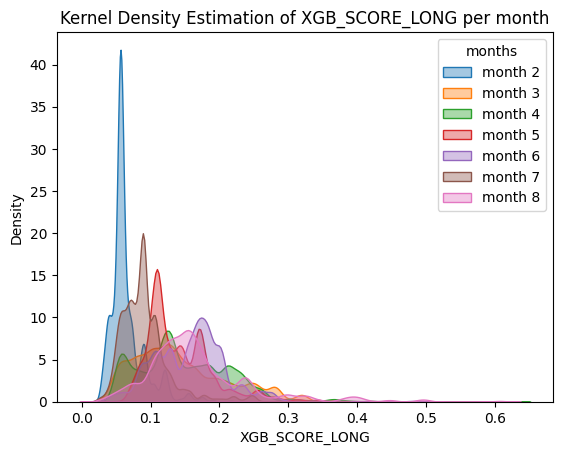

In [1245]:
for month, group in df_modelling[df_modelling['XGB_SCORE_LONG'].isnull()==False].groupby('month'):
    sns.kdeplot(group['XGB_SCORE_LONG'], label=f'month {month}', fill=True, alpha=0.4)

# Add labels and legend
plt.xlabel('XGB_SCORE_LONG')
plt.ylabel('Density')
plt.title('Kernel Density Estimation of XGB_SCORE_LONG per month')
plt.legend(title='months')

# Show the plot
plt.show()

### GINI in Time

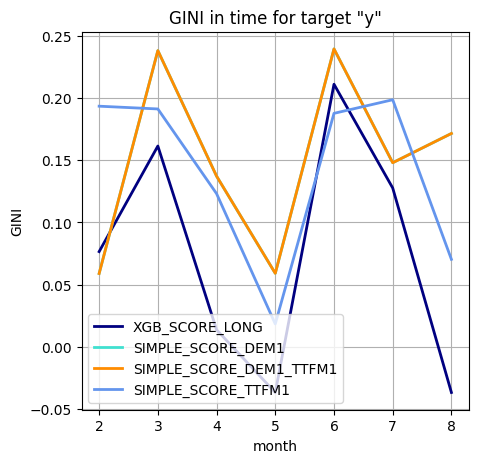

In [1246]:
from mofr.basic_evaluators.GiniInTime import GiniInTimeEvaluator

gite=GiniInTimeEvaluator()
#help(gite)

gite.d(df_modelling.dropna(subset=['XGB_SCORE_LONG', 'SIMPLE_SCORE_DEM1'])).t([('y','one')]).s(['XGB_SCORE_LONG', 'SIMPLE_SCORE_DEM1', 'SIMPLE_SCORE_DEM1_TTFM1', 'SIMPLE_SCORE_TTFM1']).tc('month')

gite.get_graph()

In [1247]:
gite.get_table()
gite.table

,XGB_SCORE_LONG,SIMPLE_SCORE_DEM1,SIMPLE_SCORE_DEM1_TTFM1,SIMPLE_SCORE_TTFM1
month,,,,
2,0.076504,0.058921,0.058921,0.193430
3,0.161407,0.238140,0.238140,0.191206
4,0.013662,0.137200,0.137200,0.123112
5,-0.036802,0.059048,0.059048,0.018333
6,0.211087,0.239490,0.239490,0.187676
7,0.127669,0.147967,0.147967,0.198613
8,-0.036753,0.171489,0.171489,0.070292
All,0.048335,0.148863,0.148863,0.126505


### ROC Curves

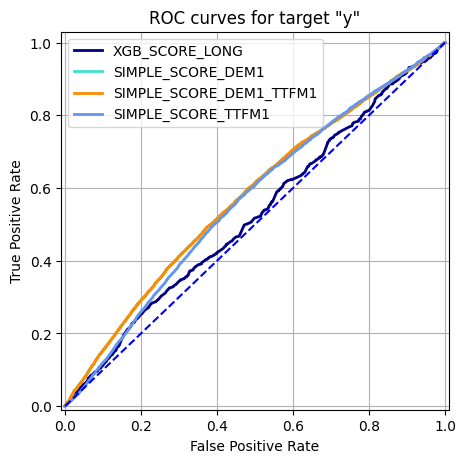

In [1248]:
from mofr.basic_evaluators.ROCCurve import ROCCurveEvaluator

rce=ROCCurveEvaluator()
#help(rce)

rce.d(df_modelling.dropna(subset=['XGB_SCORE_LONG', 'SIMPLE_SCORE_DEM1','SIMPLE_SCORE_DEM1_TTFM1', 'SIMPLE_SCORE_TTFM1', 'LR_SCORE_LONG'])).t([('y','one')]).s(['XGB_SCORE_LONG', 'SIMPLE_SCORE_DEM1','SIMPLE_SCORE_DEM1_TTFM1', 'SIMPLE_SCORE_TTFM1'])

rce.get_graph()

### LIFT in Time

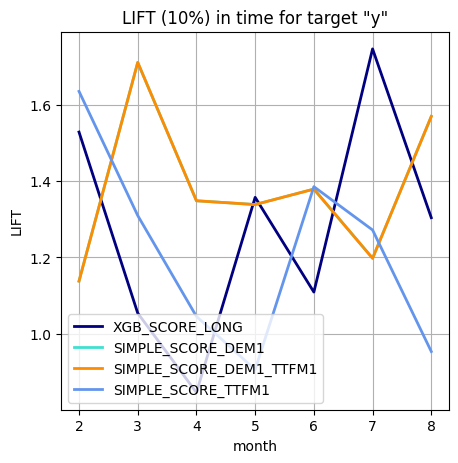

In [1249]:
try:
    from mofr.basic_evaluators.LiftInTime import LiftInTimeEvaluator

    lite=LiftInTimeEvaluator()
    #help(lite)

    lite.d(df_modelling.dropna(subset=['XGB_SCORE_LONG', 'SIMPLE_SCORE_DEM1'])).t([('y','one')]).s(['XGB_SCORE_LONG', 'SIMPLE_SCORE_DEM1', 'SIMPLE_SCORE_DEM1_TTFM1', 'SIMPLE_SCORE_TTFM1']).tc('month')

    lite.get_graph()

except:
    pass

In [1250]:
try:
    lite.get_table()
    display(lite.table)
except:
    pass

,XGB_SCORE_LONG,SIMPLE_SCORE_DEM1,SIMPLE_SCORE_DEM1_TTFM1,SIMPLE_SCORE_TTFM1
month,,,,
2,1.528183,1.138009,1.138009,1.634682
3,1.054325,1.710395,1.710395,1.309723
4,0.846471,1.348336,1.348336,1.045648
5,1.357342,1.338467,1.338467,0.906316
6,1.109383,1.378876,1.378876,1.385247
7,1.745791,1.197847,1.197847,1.271871
8,1.304036,1.569049,1.569049,0.953846
All,1.111004,1.439175,1.439175,1.167835


### Correlations

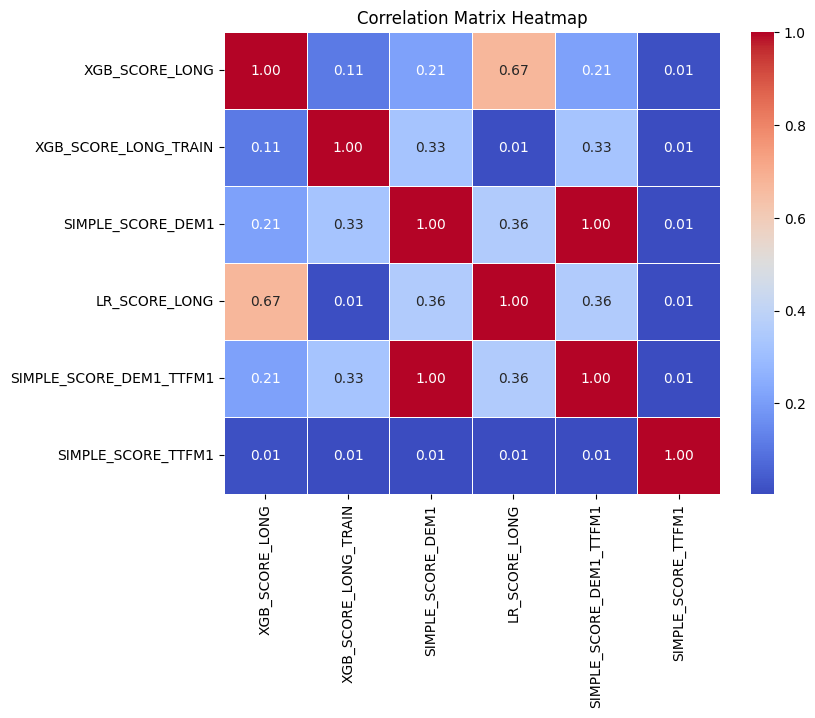

In [1251]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix after dropping NaN values
corr_matrix = df_modelling[['XGB_SCORE_LONG', 'XGB_SCORE_LONG_TRAIN', 'SIMPLE_SCORE_DEM1', 'LR_SCORE_LONG', 'SIMPLE_SCORE_DEM1_TTFM1', 'SIMPLE_SCORE_TTFM1']].dropna().corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

In [1252]:
# from bokeh.plotting import figure, show, output_file
# from bokeh.models import ColumnDataSource

# df_filtered['datetime'] = pd.to_datetime(df_filtered['datetime'])
# df_top100['datetime'] = pd.to_datetime(df_top100['datetime'])


# # Prepare the data sources for Bokeh
# source_filtered = ColumnDataSource(df_filtered)
# source_top100 = ColumnDataSource(df_top100)

# # Output to an HTML file
# output_file("bokeh_plot.html")

# # Create a figure with manually set x and y axis ranges
# p = figure(x_axis_type="datetime", title="Mid Price Over Time", sizing_mode='stretch_both',
#            x_range=(df_filtered['datetime'].min(), df_filtered['datetime'].max()),  # Ensure x-axis range covers both datasets
#            y_range=(df_filtered['mid_price'].min(), df_filtered['mid_price'].max()))  # Ensure y-axis range covers the mid_price

# p.xaxis.axis_label = 'Date'
# p.yaxis.axis_label = 'Mid Price'

# # Plot df_filtered data (orange plus signs)
# p.scatter('datetime', 'mid_price', source=source_filtered, color='orange', marker='x', size=10, legend_label='Filtered Data')

# # Plot df_top100 data (red dots)
# p.scatter('datetime', 'mid_price', source=source_top100, color='green', marker='circle', size=8, legend_label='Top 100 Data')

# # Customize the plot
# p.legend.location = "top_left"
# p.legend.click_policy = "hide"  # Allows clicking on the legend to hide/show the data

# # Show the plot in the browser
# show(p)

In [1253]:
# print(df_modelling[df_modelling['week']==6]['XGB_SCORE_LONG_TRAIN'].apply(lambda x: x).value_counts())

# print(df_modelling[df_modelling['week']==9]['XGB_SCORE_LONG'].apply(lambda x: x).value_counts())
# print(df_modelling[df_modelling['week']==9]['XGB_SCORE_LONG'].apply(lambda x: np.log(x/(1-x))-np.log(0.38/(1-0.38))).value_counts())

In [1254]:
#df_filtered[['price_diff', 'price_diff2']].describe()

## Short models

In [1255]:
df_filtered['price_diff']=df_filtered['lag_price_predicted']-df_filtered['bid_price'] #using production logic
#df_filtered['price_diff2']=df_filtered['fair_price']-df_filtered['bid_price'] #using Marek's logic with kalman filter
#df_filtered['price_diff3']=df_filtered['fair_price']-df_filtered['bid_price'] #using Marek's logic without kalman filter

In [1256]:
df_modelling=df_filtered.replace([np.inf, -np.inf], None).dropna(subset=feature_cols+['profit_long', 'profit_short']).reset_index(drop=True)

In [1257]:
df_modelling['one']=1

In [1258]:
#df_modelling=df_modelling[(df_modelling['price_diff']<-0.01)]
#df_modelling=df_modelling[(df_modelling['predicted_return']<1)]
#df_modelling=df_modelling[(df_modelling['MACD_12_26']<-0.05)]


# df_modelling=df_modelling[(df_modelling['price_diff2']<-0.01)]
#df_modelling=df_modelling[(df_modelling['ret']<0)]

df_modelling=df_modelling[(df_modelling['ba_spread']<ba_max)]
#df_modelling=df_modelling[(df_modelling['month']<8)]
df_modelling=df_modelling[df_modelling['timestamp'].apply(lambda x: x.hour>8 and  x.hour<17)]

### XGBoost

In [1259]:
df_modelling['y']=(df_modelling['profit_short']>target_profit_threshold).apply(int)
df_modelling['y'].value_counts()

y
0    181831
1     23234
Name: count, dtype: int64

In [1260]:
df_modelling['y'].value_counts(normalize=True)

y
0    0.886699
1    0.113301
Name: proportion, dtype: float64

In [1261]:
result=[]
for feat in feature_cols:
    gini=mofr.metrics.gini(df_modelling['y'], df_modelling[feat])
    result.append((feat,gini))
    
df_result = pd.DataFrame(result, columns=['Feature', 'Gini'])

# Sort DataFrame by the absolute value of the 'Gini' column
df_result_sorted = df_result.reindex(df_result['Gini'].abs().sort_values(ascending=False).index)

# Display sorted DataFrame
df_result_sorted

,Feature,Gini
0,MACD_12_26,-0.087730
2,price_diff,-0.082832
1,VII_lag_5,-0.024338
3,ba_spread,-0.016157


In [1262]:
# Create a new column to store the XGB_SCORE
df_modelling['XGB_SCORE_SHORT'] = None

# Sort the data by date
df_modelling = df_modelling.sort_values('date')

# Generate weekly ranges: We're going to use sliding windows with 2 weeks for training and 1 week for scoring
weeks = pd.date_range(df_modelling['date'].min(), df_modelling['date'].max(), freq='W')

for i in range(len(weeks) - 7):  # We subtract 5 to ensure we have enough weeks for a 4-week train and 1-week test
    train_start = weeks[i+3]
    train_end = weeks[i+3 + 3]  # End of the 4-week training period
    test_start = weeks[i]
    test_end = weeks[i + 3] # End of the 1-week test period\
    
    valid_start = weeks[i+3 + 3]
    valid_end = weeks[i+3 + 4] # End of the 1-week test period\
    
    #print(f'{test_start} and {test_end}')
    
    # Training data: last 2 weeks
    train_data = df_modelling[(df_modelling['date'] >= train_start) & (df_modelling['date'] < train_end)]
    
    # Testing data: next 1 week
    test_data = df_modelling[(df_modelling['date'] >= test_start) & (df_modelling['date'] < test_end)]
    
    # Testing data: next 1 week
    valid_data = df_modelling[(df_modelling['date'] >= valid_start) & (df_modelling['date'] < valid_end)]
    
    # Skip if there isn't enough data for the period
    if train_data.empty or test_data.empty:
        continue

 # Split into features and target
    X_train, y_train = train_data[feature_cols].apply(pd.to_numeric, errors='coerce'), train_data['y']
    X_test, y_test = test_data[feature_cols].apply(pd.to_numeric, errors='coerce'), test_data['y']
    X_valid, y_valid = valid_data[feature_cols].apply(pd.to_numeric, errors='coerce'), valid_data['y']


    # Create DMatrix for XGBoost (required for early stopping)
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dtest = xgb.DMatrix(X_test, label=y_test)
    dvalid = xgb.DMatrix(X_valid, label=y_valid)


   # Set up the parameters for XGBoost
    params = {
    'objective': 'binary:logistic',  # For binary classification
    'eval_metric': 'auc',  # Use log-loss to evaluate performance
    'max_depth': 2,  # Prevent overfitting by limiting tree depth
    'gamma': 5,  # Regularization to reduce overfitting
    'min_child_weight': 15,  # Regularization to reduce overfitting

    'base_score': df_modelling['y'].mean()
    }

    # Set up evaluation list
    evals = [(dtrain, 'train'), (dtest, 'test')]

    # Train the model with early stopping
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=100,  # Maximum number of boosting rounds
        evals=evals,
        early_stopping_rounds=3,  # Stop if test error doesn't improve after 10 rounds
        verbose_eval=True  # Show progress
    )

    # Predict for the training and testing periods
    predictions_train = model.predict(dtrain)
    predictions = model.predict(dvalid)
    
    lr_model = LogisticRegression()
    lr_model.fit(X_train, y_train)
    
    predictions_lr=lr_model.predict_proba(X_valid)[:, 1]

    print(train_start)
    print(train_end)
    
#     # Plot the first tree in the model (tree_index=0)
#     xgb.plot_tree(model, num_trees=0)
#     plt.rcParams['figure.figsize'] = [50, 10]  # Adjust the size as needed
#     plt.show()

#     # Plot feature importance
#     plt.figure(figsize=(10, 6))
#     xgb.plot_importance(model, importance_type='weight')  # You can change importance_type to 'gain' or 'cover'
#     plt.show()

    # Insert predictions into the original DataFrame
    df_modelling.loc[train_data.index, 'XGB_SCORE_SHORT_TRAIN'] = predictions_train
    df_modelling.loc[valid_data.index, 'XGB_SCORE_SHORT'] = predictions
    df_modelling.loc[valid_data.index, 'LR_SCORE_SHORT'] = predictions_lr

[0]	train-auc:0.62660	test-auc:0.49510
[1]	train-auc:0.70579	test-auc:0.54671
[2]	train-auc:0.73690	test-auc:0.52002
[3]	train-auc:0.74263	test-auc:0.53351
2024-01-28 00:00:00
2024-02-18 00:00:00
[0]	train-auc:0.63035	test-auc:0.52819
[1]	train-auc:0.68559	test-auc:0.49544
[2]	train-auc:0.66909	test-auc:0.52117
[3]	train-auc:0.71206	test-auc:0.53062
[4]	train-auc:0.72720	test-auc:0.50399
[5]	train-auc:0.72002	test-auc:0.51613
[6]	train-auc:0.73169	test-auc:0.49961
2024-02-04 00:00:00
2024-02-25 00:00:00
[0]	train-auc:0.64785	test-auc:0.50129
[1]	train-auc:0.68506	test-auc:0.40330
[2]	train-auc:0.71000	test-auc:0.41099
[3]	train-auc:0.71363	test-auc:0.42496
2024-02-11 00:00:00
2024-03-03 00:00:00
[0]	train-auc:0.59296	test-auc:0.54279
[1]	train-auc:0.63877	test-auc:0.51029
[2]	train-auc:0.65722	test-auc:0.45097
2024-02-18 00:00:00
2024-03-10 00:00:00
[0]	train-auc:0.59006	test-auc:0.45568
[1]	train-auc:0.67610	test-auc:0.51236
[2]	train-auc:0.69278	test-auc:0.54139
[3]	train-auc:0.69444

[1]	train-auc:0.59773	test-auc:0.54432
[2]	train-auc:0.61382	test-auc:0.56879
[3]	train-auc:0.61575	test-auc:0.56764
[4]	train-auc:0.64687	test-auc:0.54583
[5]	train-auc:0.65531	test-auc:0.52191
2024-07-28 00:00:00
2024-08-18 00:00:00


In [1263]:
#
print('The Lift on the train set is: '+ str(mofr.metrics.lift(df_modelling[df_modelling['XGB_SCORE_SHORT_TRAIN'].isnull()==False]['y'], df_modelling[df_modelling['XGB_SCORE_SHORT_TRAIN'].isnull()==False]['XGB_SCORE_SHORT_TRAIN'])))
print('The gini on the train set is: '+ str(mofr.metrics.gini(df_modelling[df_modelling['XGB_SCORE_SHORT_TRAIN'].isnull()==False]['y'], df_modelling[df_modelling['XGB_SCORE_SHORT_TRAIN'].isnull()==False]['XGB_SCORE_SHORT_TRAIN'])))
# print('The accuracy on the test set is: '+ str(mofr.metrics.accuracy_score(df_modelling[df_modelling['XGB_SCORE_SHORT'].isnull()==False]['y'], df_modelling[df_modelling['XGB_SCORE_SHORT'].isnull()==False]['XGB_SCORE_SHORT'].apply(lambda x: int(x>0.5)))))
print('\n')
print('The Lift on the test set is: '+ str(mofr.metrics.lift(df_modelling[df_modelling['XGB_SCORE_SHORT'].isnull()==False]['y'], df_modelling[df_modelling['XGB_SCORE_SHORT'].isnull()==False]['XGB_SCORE_SHORT'])))
print('The gini on the test set is: '+ str(mofr.metrics.gini(df_modelling[df_modelling['XGB_SCORE_SHORT'].isnull()==False]['y'], df_modelling[df_modelling['XGB_SCORE_SHORT'].isnull()==False]['XGB_SCORE_SHORT'])))
# print('The accuracy on the test set is: '+ str(mofr.metrics.accuracy_score(df_modelling[df_modelling['XGB_SCORE_SHORT'].isnull()==False]['y'], df_modelling[df_modelling['XGB_SCORE_SHORT'].isnull()==False]['XGB_SCORE_SHORT'].apply(lambda x: int(x>0.5)))))
print('\n')
# Sort the DataFrame by the XGB_SCORE_SHORT column in descending order
df_modelling['CURRENT_LOGIC']=((df_modelling['MACD_12_26']<-0.1)&(df_modelling['price_diff']<-0.1)&(df_modelling['predicted_return']<1)&(df_modelling['XGB_SCORE_SHORT'].isnull()==False)).apply(int)
df_modelling['SIMPLE_SCORE_TTFM1']=(-df_modelling['MACD_12_26']-df_modelling['price_diff']+0.1*df_modelling['VII_lag_5'])#*df_modelling['volatility_day']
df_modelling['SIMPLE_SCORE_DEM1_TTFM1']=-df_modelling['MACD_12_26']-df_modelling['price_diff']
df_modelling['SIMPLE_SCORE_DEM1']=(-df_modelling['MACD_12_26']-df_modelling['price_diff'])#*(-df_modelling['volatility_day']+1)

n=sum(df_modelling['CURRENT_LOGIC'])
df_top100 = df_modelling.sort_values(by='XGB_SCORE_SHORT', ascending=False).head(n)
df_top100_train = df_modelling.sort_values(by='XGB_SCORE_SHORT_TRAIN', ascending=False).head(n)
df_top100_simple = df_modelling.sort_values(by='SIMPLE_SCORE_DEM1_TTFM1', ascending=False).head(n)
df_top100_lr = df_modelling.sort_values(by='LR_SCORE_SHORT', ascending=False).head(n)
df_top100_simple2 = df_modelling.sort_values(by='SIMPLE_SCORE_DEM1', ascending=False).head(n)
df_top100_simple3 = df_modelling.sort_values(by='SIMPLE_SCORE_TTFM1', ascending=False).head(n)


# Calculate precision based on the top 100 observations
precision_test, profit_test = df_top100['y'].sum()/n, df_top100['profit_short'].sum()-n*0.05
precision_train, profit_train = df_top100_train['y'].sum()/n, df_top100_train['profit_short'].sum()-n*0.05
precision_simple, profit_simple = df_top100_simple['y'].sum()/n, df_top100_simple['profit_short'].sum()-n*0.05
precision, profit=df_modelling[df_modelling['CURRENT_LOGIC']==1]['y'].mean(), df_modelling[df_modelling['CURRENT_LOGIC']==1]['profit_short'].sum()-n*0.05
precision_lr, profit_lr = df_top100_lr['y'].sum()/n, df_top100_lr['profit_short'].sum()-n*0.05
precision_simple2, profit_simple2 = df_top100_simple2['y'].sum()/n, df_top100_simple2['profit_short'].sum()-n*0.05
precision_simple3, profit_simple3 = df_top100_simple3['y'].sum()/n, df_top100_simple3['profit_short'].sum()-n*0.05





# Create a DataFrame with the precision data
precision_data = {
    'Set': ['Train', 'Test', 'LR', 'Simple','Simple2', 'Simple3', 'Current Model'],
    'Top N Observations': [n, n, n, n, n, n, n],
    'Precision': [precision_train, precision_test, precision_lr, precision_simple,precision_simple2,precision_simple3,precision],
    'Profit': [profit_train, profit_test, profit_lr, profit_simple,profit_simple2,profit_simple3,profit],

    'Unique Days': [
        len(df_top100_train['date'].unique()), 
        len(df_top100['date'].unique()), 
        len(df_top100_lr['date'].unique()), 

        len(df_top100_simple['date'].unique()), 
        len(df_top100_simple2['date'].unique()), 
        len(df_top100_simple3['date'].unique()), 

        len(df_modelling[df_modelling['CURRENT_LOGIC']==1]['date'].unique())
    ]
}

# Create DataFrame to store the results
df_precision = pd.DataFrame(precision_data)
df_precision

The Lift on the train set is: 2.8714770720674454
The gini on the train set is: 0.423916876344939


The Lift on the test set is: 1.1269487616185967
The gini on the test set is: 0.058840196071086925




,Set,Top N Observations,Precision,Profit,Unique Days
0,Train,610,0.637705,265.75,31
1,Test,610,0.132787,-46.39,32
2,LR,610,0.208197,-104.14,36
3,Simple,610,0.203279,-135.40,54
4,Simple2,610,0.203279,-135.40,54
5,Simple3,610,0.121311,-88.33,101
6,Current Model,610,0.245902,-46.84,63


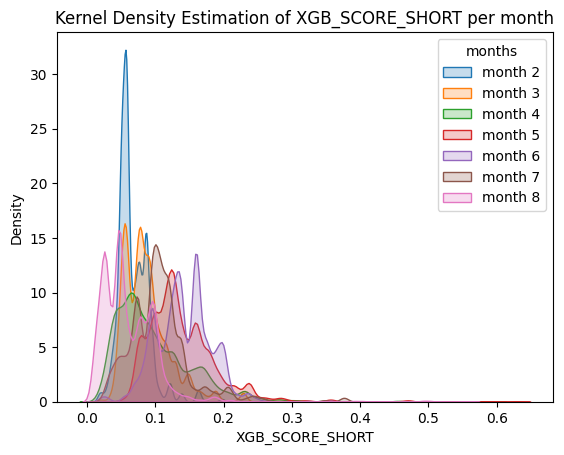

In [1264]:
for month, group in df_modelling[df_modelling['XGB_SCORE_SHORT'].isnull()==False].groupby('month'):
    sns.kdeplot(group['XGB_SCORE_SHORT'], label=f'month {month}', fill=True, alpha=0.25)

# Add labels and legend
plt.xlabel('XGB_SCORE_SHORT')
plt.ylabel('Density')
plt.title('Kernel Density Estimation of XGB_SCORE_SHORT per month')
plt.legend(title='months')

# Show the plot
plt.show()

### GINI in Time

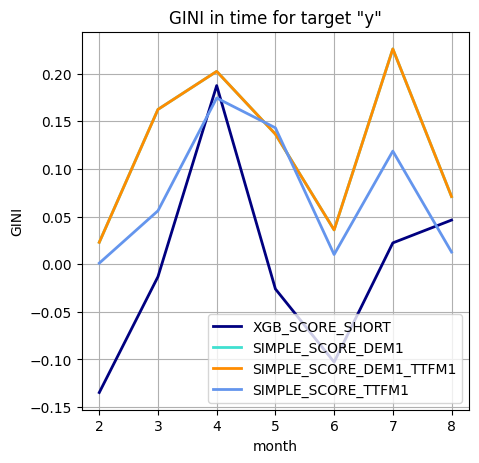

In [1265]:
from mofr.basic_evaluators.GiniInTime import GiniInTimeEvaluator

gite=GiniInTimeEvaluator()
#help(gite)

gite.d(df_modelling.dropna(subset=['XGB_SCORE_SHORT', 'SIMPLE_SCORE_DEM1','SIMPLE_SCORE_DEM1_TTFM1', 'SIMPLE_SCORE_TTFM1', 'LR_SCORE_SHORT'])).t([('y','one')]).s(['XGB_SCORE_SHORT', 'SIMPLE_SCORE_DEM1','SIMPLE_SCORE_DEM1_TTFM1', 'SIMPLE_SCORE_TTFM1']).tc('month')

gite.get_graph()


In [1266]:
gite.get_table()
gite.table

,XGB_SCORE_SHORT,SIMPLE_SCORE_DEM1,SIMPLE_SCORE_DEM1_TTFM1,SIMPLE_SCORE_TTFM1
month,,,,
2,-0.134711,0.022929,0.022929,0.001072
3,-0.013094,0.162432,0.162432,0.056075
4,0.187433,0.202352,0.202352,0.174377
5,-0.026006,0.136511,0.136511,0.143101
6,-0.102732,0.035961,0.035961,0.010135
7,0.022342,0.225934,0.225934,0.118668
8,0.046287,0.070965,0.070965,0.012749
All,0.058840,0.116290,0.116290,0.078271


### ROC Curves

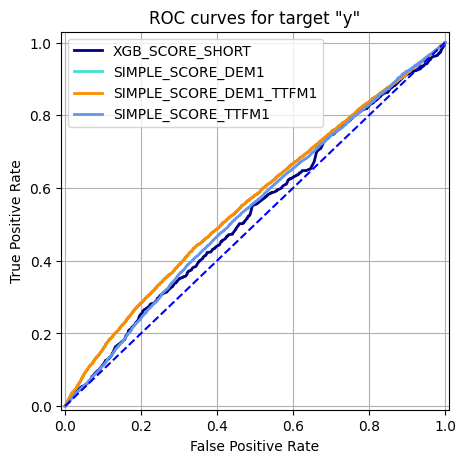

In [1267]:
from mofr.basic_evaluators.ROCCurve import ROCCurveEvaluator

rce=ROCCurveEvaluator()
#help(rce)

rce.d(df_modelling.dropna(subset=['XGB_SCORE_SHORT', 'SIMPLE_SCORE_DEM1','SIMPLE_SCORE_DEM1_TTFM1', 'SIMPLE_SCORE_TTFM1', 'LR_SCORE_SHORT'])).t([('y','one')]).s(['XGB_SCORE_SHORT', 'SIMPLE_SCORE_DEM1','SIMPLE_SCORE_DEM1_TTFM1', 'SIMPLE_SCORE_TTFM1'])

rce.get_graph()

### LIFT in Time

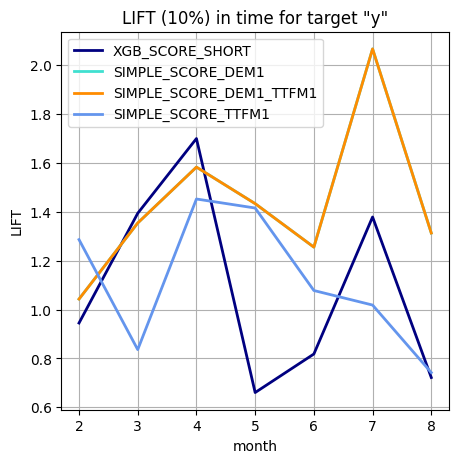

In [1268]:
try:
    from mofr.basic_evaluators.LiftInTime import LiftInTimeEvaluator

    lite=LiftInTimeEvaluator()
    #help(lite)

    lite.d(df_modelling.dropna(subset=['XGB_SCORE_SHORT', 'SIMPLE_SCORE_DEM1','SIMPLE_SCORE_DEM1_TTFM1', 'SIMPLE_SCORE_TTFM1'])).t([('y','one')]).s(['XGB_SCORE_SHORT', 'SIMPLE_SCORE_DEM1','SIMPLE_SCORE_DEM1_TTFM1', 'SIMPLE_SCORE_TTFM1']).tc('month')

    lite.get_graph()
except:
    pass

In [1269]:
try:
    lite.get_table()
    display(lite.table)
except:
    pass

,XGB_SCORE_SHORT,SIMPLE_SCORE_DEM1,SIMPLE_SCORE_DEM1_TTFM1,SIMPLE_SCORE_TTFM1
month,,,,
2,0.945010,1.043077,1.043077,1.286462
3,1.394190,1.354470,1.354470,0.836200
4,1.700175,1.583253,1.583253,1.452703
5,0.660467,1.433699,1.433699,1.415777
6,0.818177,1.255655,1.255655,1.078110
7,1.379054,2.067106,2.067106,1.018574
8,0.721942,1.313274,1.313274,0.742114
All,1.126949,1.480081,1.480081,1.097327


### Correlations

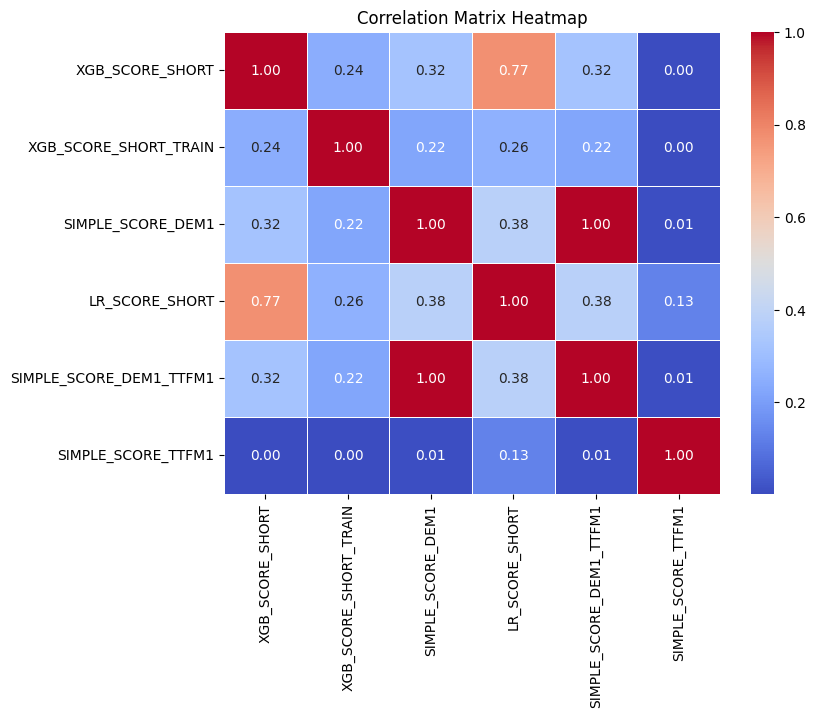

In [1270]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix after dropping NaN values
corr_matrix = df_modelling[['XGB_SCORE_SHORT', 'XGB_SCORE_SHORT_TRAIN', 'SIMPLE_SCORE_DEM1', 'LR_SCORE_SHORT', 'SIMPLE_SCORE_DEM1_TTFM1', 'SIMPLE_SCORE_TTFM1']].dropna().corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

In [1271]:
# from bokeh.plotting import figure, show, output_file
# from bokeh.models import ColumnDataSource

# df_filtered['datetime'] = pd.to_datetime(df_filtered['datetime'])
# df_top100['datetime'] = pd.to_datetime(df_top100['datetime'])


# # Prepare the data sources for Bokeh
# source_filtered = ColumnDataSource(df_filtered)
# source_top100 = ColumnDataSource(df_top100)

# # Output to an HTML file
# output_file("bokeh_plot.html")

# # Create a figure with manually set x and y axis ranges
# p = figure(x_axis_type="datetime", title="Mid Price Over Time", sizing_mode='stretch_both',
#            x_range=(df_filtered['datetime'].min(), df_filtered['datetime'].max()),  # Ensure x-axis range covers both datasets
#            y_range=(df_filtered['mid_price'].min(), df_filtered['mid_price'].max()))  # Ensure y-axis range covers the mid_price

# p.xaxis.axis_label = 'Date'
# p.yaxis.axis_label = 'Mid Price'

# # Plot df_filtered data (orange plus signs)
# p.scatter('datetime', 'mid_price', source=source_filtered, color='orange', marker='x', size=10, legend_label='Filtered Data')

# # Plot df_top100 data (red dots)
# p.scatter('datetime', 'mid_price', source=source_top100, color='red', marker='circle', size=8, legend_label='Top 100 Data')

# # Customize the plot
# p.legend.location = "top_left"
# p.legend.click_policy = "hide"  # Allows clicking on the legend to hide/show the data

# # Show the plot in the browser
# show(p)